# Multi-energy multimode phase retrieval parallel
Minimal use of `phase_retrieval_core_multienergy_multimode_parallel.py`.

In [1]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sys, os
from os.path import join
sys.path.append("/home/user/Moritz/msc/RB2004/code/FTH-Phase_Retrieval/library")
import phase_retrieval_core_multienergy as pr
#import phase_retrieval_core_multienergy_multimode_parallel as pr

In [2]:
data = np.load(Path("/home/user/Moritz/msc/RB2004/data.npz"))
holograms = data["holograms"]
energy_ev = data["energy"]
mask_pixel = data["mask_pixel"]
supportmask = np.load("/home/user/Moritz/msc/RB2004/suppmask.npz.npy")

optical_constants = np.load(Path("/home/user/Moritz/msc/RB2004/data/refractive_index_constraints.npz"))
constraint_energy_ev = optical_constants["energy_ev"]
beta = optical_constants["beta"]
delta = optical_constants["delta"]

#if not np.allclose(energy_ev, constraint_energy_ev):
beta = np.interp(energy_ev, constraint_energy_ev, beta)
delta = np.interp(energy_ev, constraint_energy_ev, delta)

assert holograms.shape[0] == energy_ev.size == beta.size == delta.size
assert supportmask.shape == holograms.shape[1:]

In [3]:
bin_factor = 2
support_crop_pad = bin_factor
supportmask = np.load("/home/user/Moritz/msc/RB2004/suppmask.npz.npy")


def _bin_2d(array, factor, reducer="mean"):
    array = np.asarray(array)
    if array.ndim != 2:
        raise ValueError("Expected a 2D array.")
    if factor <= 0:
        raise ValueError("bin_factor must be a positive integer.")

    height, width = array.shape
    trimmed_height = height - (height % factor)
    trimmed_width = width - (width % factor)
    array = array[:trimmed_height, :trimmed_width]
    reshaped = array.reshape(
        trimmed_height // factor,
        factor,
        trimmed_width // factor,
        factor,
    )

    if reducer == "mean":
        return reshaped.mean(axis=(1, 3))
    if reducer == "max":
        return reshaped.max(axis=(1, 3))
    raise ValueError("reducer must be 'mean' or 'max'.")


def _bin_stack(stack, factor, reducer="mean"):
    stack = np.asarray(stack)
    if stack.ndim == 2:
        return _bin_2d(stack, factor, reducer=reducer)
    if stack.ndim != 3:
        raise ValueError("Expected a 2D image or 3D energy stack.")
    return np.stack([
        _bin_2d(image, factor, reducer=reducer) for image in stack
    ])


def _support_crop_slices(supportmask, pad, factor):
    supportmask = np.asarray(supportmask)
    support_pixels = np.argwhere(supportmask > 0)
    if not support_pixels.size:
        return (slice(None), slice(None))

    row_min, col_min = support_pixels.min(axis=0)
    row_max, col_max = support_pixels.max(axis=0) + 1
    height, width = supportmask.shape

    row_min = max(0, row_min - pad)
    col_min = max(0, col_min - pad)
    row_max = min(height, row_max + pad)
    col_max = min(width, col_max + pad)

    c0, c1 = (row_min + row_max) /2, (col_min + col_max) /2

    return c0, c1


c0, c1 = _support_crop_slices(
    np.load("/home/user/Moritz/msc/RB2004/suppmask.npz.npy"),
    support_crop_pad,
    bin_factor,
)


def center_and_crop(img, c0, c1, frac=0.5):
    center0, center1 = img.shape[0] // 2, img.shape[1] // 2
    shift0, shift1 = int(center0 - np.round(c0)), int(center1 - np.round(c1))
    shifted = np.roll(img, (shift0, shift1), axis=(0, 1))

    h = int(img.shape[0] * frac)//2
    w = int(img.shape[1] * frac)//2
    
    return shifted[(img.shape[0] // 2) -h:(img.shape[0] // 2) + h, (img.shape[1] // 2) - w:(img.shape[1] // 2) + w]


In [4]:

supportmask = center_and_crop(supportmask, c0, c1, frac=0.5)

holograms = _bin_stack(
    data["holograms"],
    bin_factor,
    reducer="mean",
)
mask_pixel = _bin_stack(
    data["mask_pixel"],
    bin_factor,
    reducer="max",
)

supportmask = (supportmask > 0).astype(supportmask.dtype)

assert holograms.shape[0] == energy_ev.size == beta.size == delta.size
assert supportmask.shape == holograms.shape[1:]
assert mask_pixel.shape == holograms.shape


  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/asyncio/base_events.py", line 604, in run_forever
    self._run_once()
  File "/home/user/miniforge3/envs/maxiv_local/lib/python3.11/asyncio/base_events.py", line 1909, in _run_once
    handle._run()
  File "/home/user/m

interactive(children=(FloatRangeSlider(value=(9.491102234684877, 81410.19737861928), description='contrast', l…

interactive(children=(IntSlider(value=0, description='nr', max=14), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

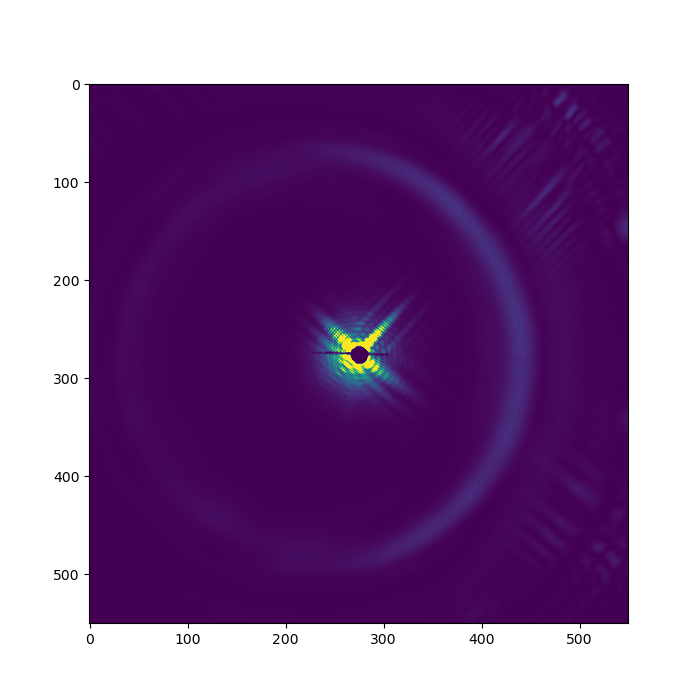

In [5]:
from interactive import cimshow
%matplotlib widget
cimshow(holograms)

In [6]:
import cupy as cp
import numpy as np

if not hasattr(cp, 'errstate'):
    cp.errstate = np.errstate

In [7]:
from importlib import reload
reload(pr)
recipe = {
    # Per-energy update schedule repeated during every outer iteration.
    "inner_mode": ["HAPRE", "ER"],       # Algorithm stages; a string is accepted for one stage.
    "inner_Nit": [700, 50],               # Iterations in each inner stage.
    "RL_it": [50, 50],                           # Partial-coherence iterations.
    "RL_freq": [50, 20],                       # Partial-coherence update interval.
    "outer_iterations": 10,              # Number of update-plus-projection cycles.
    "warmup_mode": ["HAPRE", "ER", "HAPRE", "ER"],      # Independent stages before energies are coupled.
    "warmup_Nit": [700, 50, 700, 50],                      # Warmup iterations; zero disables warmup.
    "warmup_RL_it": [0, 0, 50, 50],                           # Partial-coherence iterations.
    "warmup_RL_freq": [1e9, 1e9, 50, 20],                       # Partial-coherence update interval.
    "shuffle_energies": True,             # Randomize energy update order each outer cycle.
    "random_seed": None,                  # Seed for energy-order randomization.
    # Scalars are broadcast to all inner stages; lists customize each stage.
    "beta_zero": 0.5,                     # Beta-schedule starting/reference value.
    "beta_mode": "arctan",               # Beta schedule name or one array per stage.
    "alpha_zero": 0.0,                    # TV-step strength; zero disables TV.
    "alpha_mode": "const",               # Alpha schedule name or array.
    "TV_freq": 1e9,                       # TV update interval.
    "warmup_beta_zero": None,             # None inherits beta_zero.
    "warmup_beta_mode": None,             # None inherits beta_mode.
    "warmup_alpha_zero": None,            # None inherits alpha_zero.
    "warmup_alpha_mode": None,            # None inherits alpha_mode.
    "warmup_TV_freq": None,               # None inherits TV_freq.
    "plot_every": 1e9,                    # Error sampling/plot interval.
    "average_img": 1,                     # Number of best late iterates to average.
    "Fourier_last": True,                 # Finish each stage with its Fourier constraint.
    "final_fourier_constraint": False,     # Finish final outputs on measured amplitudes.
    "hologram_intensity_cutoff_vmin": -1, # Percentile baseline subtraction; negative disables it.
    # Cross-energy object projection.
    "projection_model": "rank1_spectral",           # "none", "svd", or "rank1_spectral".
    "rank": 1,                            # Retained residual rank for the SVD model.
    "projection_every": 15,                # Outer-cycle interval between projections.
    "projection_relaxation": 1.0,         # 0 keeps current objects; 1 applies full projection.
    "projection_constraints_inside_support_only": False, # If True, apply joint projections only inside supportmask.
    "projection_start": 0,                # First outer cycle eligible for projection.
    "projection_static_mode": "mean",    # Static object: "mean", "first", or "none".
    "energy_weights": None,               # Positive weight per energy; None means equal weights.
    "log_floor": 1e-12,                   # Object-magnitude floor before taking complex log.
    # Rank-one spectral constraints; used only by rank1_spectral.
    "spectral_constraint": "known_beta",       # "free", "kk", "known_beta", or "known_beta_kk".
    "energy_values": data["energy"],         # Strictly increasing energy axis for KK operations.
    "known_beta_spectrum": beta,          # Known absorption-like response spectrum.
    "known_delta_spectrum": None,         # Optional known dispersion-like response spectrum.
    "absorption_part": "imag",           # Whether absorption occupies "real" or "imag" part.
    "kk_sign": 1.0,                       # Sign convention multiplying the KK result.
    "kk_subtract_baseline": True,         # Remove endpoint baseline before KK.
    "kk_normalize_input": False,          # Normalize absorption before KK.
    "known_beta_normalization": "none",  # "none", "maxabs", "l2", or "std".
    "fit_known_beta_scale": True,         # Fit known-spectrum multiplicative scale.
    "fit_known_beta_offset": True,        # Fit known-spectrum additive offset.
}

fields, components, bsmasks, errors = (
    pr.multi_energy_phase_retrieval_algorithm(
        holograms,
        mask_pixel,
        supportmask,
        multi_energy_recipe=recipe,
    )
)

warmup 0
mode=HAPRE, Nit=700, RL_it=0, RL_freq=1000000000
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262


interactive(children=(FloatRangeSlider(value=(0.40967928393401165, 379.5739722763412), description='contrast',…

interactive(children=(IntSlider(value=0, description='nr', max=14), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

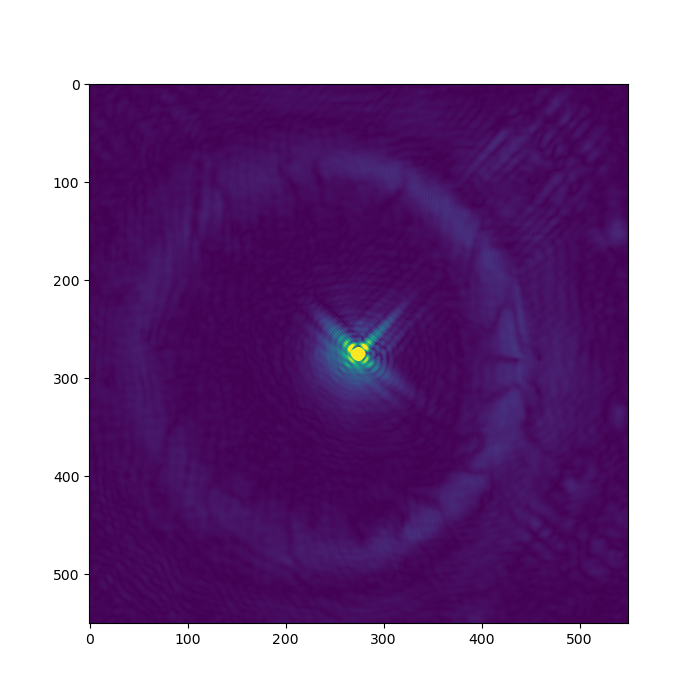

In [8]:
cimshow(np.abs((fields[:, :, :])))

interactive(children=(FloatRangeSlider(value=(0.0002598581057899016, 1.0129373167937856), description='contras…

interactive(children=(IntSlider(value=0, description='nr', max=14), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

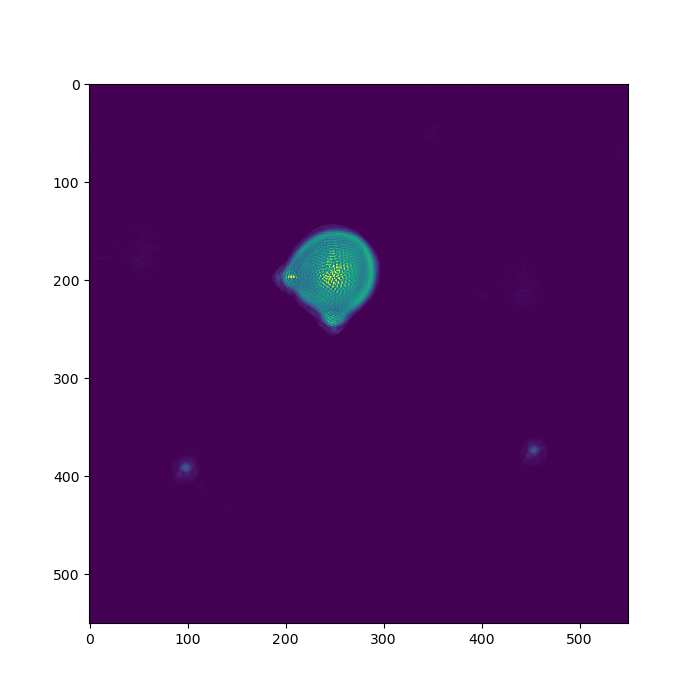

In [9]:
import interactive
cimshow(np.abs((interactive.reconstruct(fields[:, :, :]))))

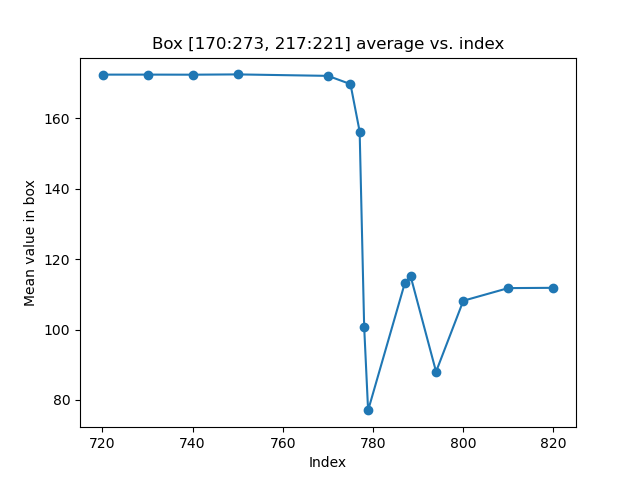

In [12]:
import numpy as np
import matplotlib.pyplot as plt

stack = np.abs(interactive.reconstruct(fields[:, :, :]))  # shape (N, H, W)

x0, y0 = 170, 221
x1, y1 = 273, 217
xmin, xmax = sorted([x0, x1])
ymin, ymax = sorted([y0, y1])

# average each image over the box -> 1D array of length N
region_means = stack[:, ymin:ymax, xmin:xmax].sum(axis=(1, 2))

plt.figure()
plt.plot(data["energy"],region_means, marker='o')
plt.xlabel("Index")
plt.ylabel("Mean value in box")
plt.title(f"Box [{xmin}:{xmax}, {ymin}:{ymax}] average vs. index")
plt.show()

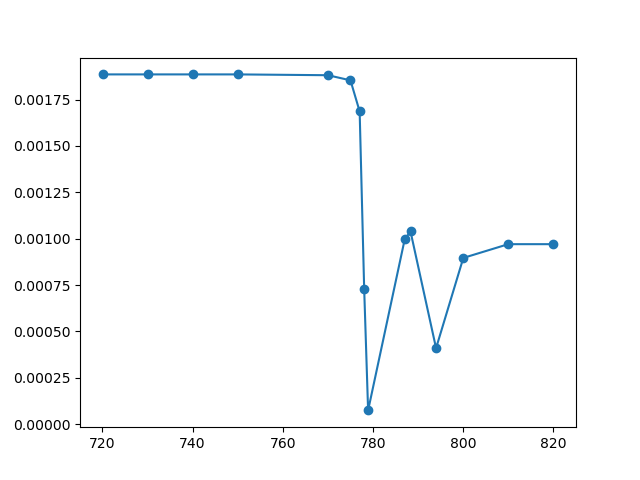

In [13]:
fig, ax = plt.subplots()
ax.plot(data["energy"], beta, marker='o', label='Measured')

interactive(children=(FloatRangeSlider(value=(0.0002598581057899016, 1.0129373167937856), description='contras…

interactive(children=(IntSlider(value=0, description='nr', max=14), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

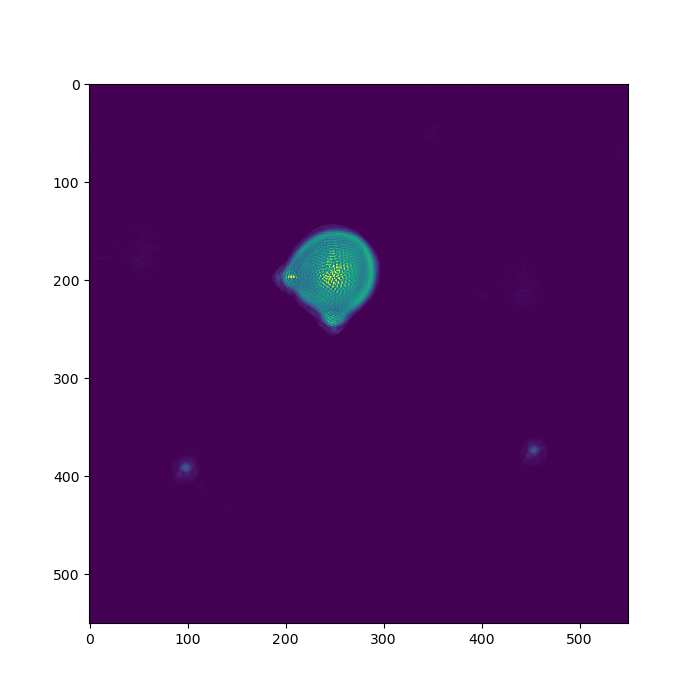

In [14]:
import interactive
from interactive import cimshow
%matplotlib widget
cimshow(np.abs(interactive.reconstruct(fields[:, :, :])))

In [ ]:
components.get('spectral_spatial_map')

In [ ]:
components.keys()

/home/user/Moritz/msc/RB2004/code/FTH-Phase_Retrieval/library/interactive.py:181: ComplexWarning: Casting complex values to real discards the imaginary part
  im = np.array(im).astype("float")


interactive(children=(FloatRangeSlider(value=(-7.76470878381936, 7.7721466073947605), description='contrast', …

(<Figure size 700x700 with 1 Axes>, <Axes: >)

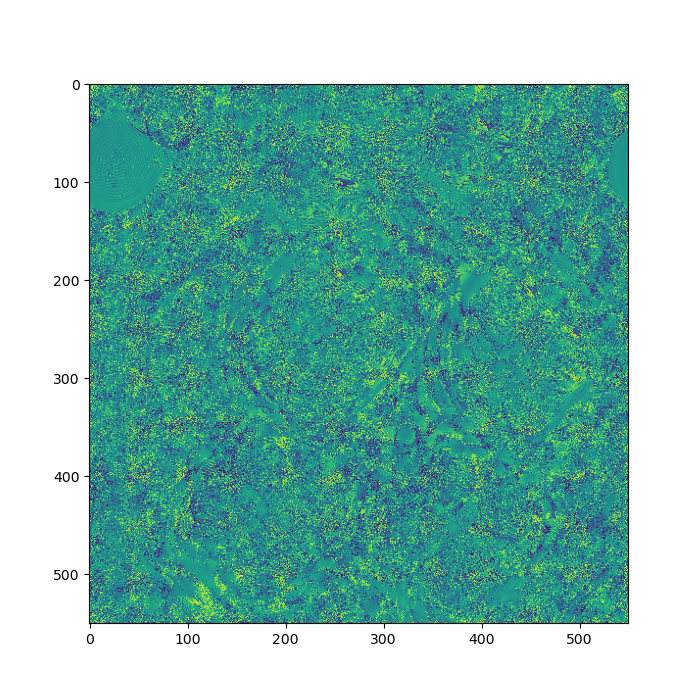

In [61]:
cimshow(components['mode_components'][0]['spectral_spatial_map'])

interactive(children=(FloatSlider(value=0.0, description='propagation[um]', layout=Layout(width='75%'), min=-1…

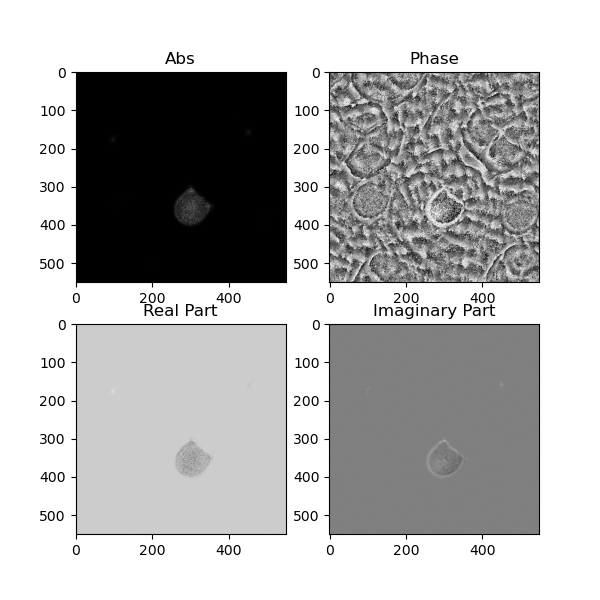

In [42]:
i = 4
_ = interactive.focusCDI((fields[i, :, :]), (fields[i, :, :]), roi = np.s_[:,:], mask = np.ones_like(fields[i, :, :]), max_prop_dist=100)

interactive(children=(FloatRangeSlider(value=(3.1207692356466206, 391.71256947241255), description='contrast',…

interactive(children=(IntSlider(value=0, description='nr', max=14), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

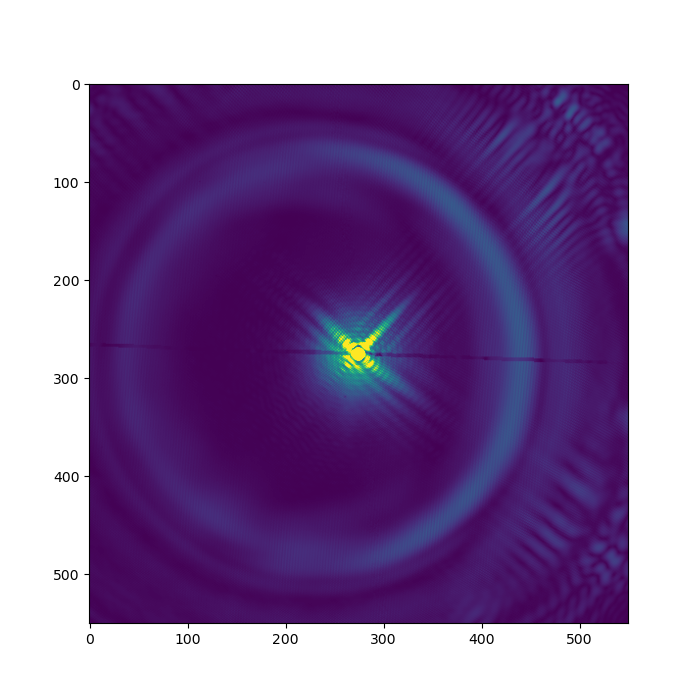

In [24]:
cimshow(np.abs(fields[:, :, :]))